In [1]:
# -- Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

In [2]:
# -- Load data 

df_customers = pd.read_csv("customers_cleaned.csv")
df_accounts = pd.read_csv("customer_accounts_cleaned.csv")
df_segments = pd.read_csv("customer_segments_cleaned.csv")

In [3]:
# -- Initial data inspection

print("Customers:", df_customers.shape)
print("Customer Accounts:", df_accounts.shape)
print("Customer Segments:", df_segments.shape)

Customers: (10000, 13)
Customer Accounts: (10000, 13)
Customer Segments: (5, 3)


In [4]:
display(df_customers.head())
display(df_accounts.head())
display(df_segments.head())

,customer_id,segment_id,surname,age,gender,geography,estimated_salary,marital_status,occupation,join_date,segment,num_dependents,preferred_contact_method
0,100096,2,Carpenter,48,Male,United States,47551.78,Married,Self-Employed,7/12/2026,Family,4,Email
1,100177,5,Crawford,82,Male,United States,15359.42,Single,Retired,9/22/2019,Senior,0,Email
2,100193,1,Owen,31,Female,Germany,67422.68,Married,Salaried Employee,7/12/2023,Retail,0,Email
3,100205,5,Campbell,65,Female,France,50019.94,Married,Retired,3/28/2024,Senior,0,Email
4,100301,2,Castro,42,Female,United Kingdom,15962.36,Married,Salaried Employee,6/27/2026,Family,3,Email


,account_id,customer_id,credit_score,tenure,balance,num_products,has_credit_card,is_active_member,exited,complaints_last_year,monthly_transactions,average_transaction_value,last_login_days
0,2867825,100096,694,5,24958.19,2,False,False,False,0,7,165.58,49
1,1419610,100177,698,0,30715.50,2,True,False,False,1,2,29.45,24
2,5614226,100193,593,2,41149.85,2,False,True,False,0,13,51.29,5
3,5108603,100205,635,2,65563.62,1,True,True,False,0,8,129.62,0
4,4744854,100301,559,1,0.00,3,True,False,False,1,8,148.26,52


,segment_id,segment_name,description
0,1,Retail,Standard personal banking customers
1,2,Family,Customers with mortgages or family accounts
2,3,Student,Students and recent graduates
3,4,Premium,High-income customers with premium products
4,5,Senior,Retired customers


In [5]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   segment_id                10000 non-null  int64  
 2   surname                   10000 non-null  object 
 3   age                       10000 non-null  int64  
 4   gender                    10000 non-null  object 
 5   geography                 10000 non-null  object 
 6   estimated_salary          10000 non-null  float64
 7   marital_status            10000 non-null  object 
 8   occupation                10000 non-null  object 
 9   join_date                 10000 non-null  object 
 10  segment                   10000 non-null  object 
 11  num_dependents            10000 non-null  int64  
 12  preferred_contact_method  10000 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1015.8+ KB


In [6]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   account_id                 10000 non-null  int64  
 1   customer_id                10000 non-null  int64  
 2   credit_score               10000 non-null  int64  
 3   tenure                     10000 non-null  int64  
 4   balance                    10000 non-null  float64
 5   num_products               10000 non-null  int64  
 6   has_credit_card            10000 non-null  bool   
 7   is_active_member           10000 non-null  bool   
 8   exited                     10000 non-null  bool   
 9   complaints_last_year       10000 non-null  int64  
 10  monthly_transactions       10000 non-null  int64  
 11  average_transaction_value  10000 non-null  float64
 12  last_login_days            10000 non-null  int64  
dtypes: bool(3), float64(2), int64(8)
memory usage: 

In [7]:
df_segments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   segment_id    5 non-null      int64 
 1   segment_name  5 non-null      object
 2   description   5 non-null      object
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes


In [8]:
# -- Check for primary keys

print(
    "Duplicate customer IDs:",
    df_customers["customer_id"].duplicated().sum()
)

print(
    "Duplicate account IDs:",
    df_accounts["account_id"].duplicated().sum()
)

print(
    "Duplicate segment IDs:",
    df_segments["segment_id"].duplicated().sum()
)

Duplicate customer IDs: 0
Duplicate account IDs: 0
Duplicate segment IDs: 0


In [9]:
# -- Check missing values

print("CUSTOMERS")
display(df_customers.isna().sum())

print("ACCOUNTS")
display(df_accounts.isna().sum())

print("SEGMENTS")
display(df_segments.isna().sum())

CUSTOMERS


customer_id                 0
segment_id                  0
surname                     0
age                         0
gender                      0
geography                   0
estimated_salary            0
marital_status              0
occupation                  0
join_date                   0
segment                     0
num_dependents              0
preferred_contact_method    0
dtype: int64

ACCOUNTS


account_id                   0
customer_id                  0
credit_score                 0
tenure                       0
balance                      0
num_products                 0
has_credit_card              0
is_active_member             0
exited                       0
complaints_last_year         0
monthly_transactions         0
average_transaction_value    0
last_login_days              0
dtype: int64

SEGMENTS


segment_id      0
segment_name    0
description     0
dtype: int64

In [10]:
# -- Boolean test

boolean_columns = [
    "has_credit_card",
    "is_active_member",
    "exited"
]

In [11]:
for col in boolean_columns:
    print(f"\n{col}")
    print(df_accounts[col].unique())


has_credit_card
[False  True]

is_active_member
[False  True]

exited
[False  True]


In [12]:
for col in boolean_columns:
    print(f"\n{col}")
    print(df_accounts[col].value_counts(dropna=False))


has_credit_card
has_credit_card
True     6993
False    3007
Name: count, dtype: int64

is_active_member
is_active_member
True     5932
False    4068
Name: count, dtype: int64

exited
exited
False    7275
True     2725
Name: count, dtype: int64


In [13]:
# -- Changing date from object to date

df_customers["join_date"] = pd.to_datetime(
    df_customers["join_date"],
    errors="coerce"
)

In [14]:
print(df_customers["join_date"].dtype)

datetime64[ns]


In [15]:
# -- Inspecting customers without segment IDs

missing_segments = df_customers[
    ~df_customers["segment_id"].isin(
        df_segments["segment_id"]
    )
]

print("Customers with unresolved segment IDs:", len(missing_segments))

Customers with unresolved segment IDs: 9


In [16]:
display(
    missing_segments[
        ["customer_id", "segment_id"]
    ]
)

,customer_id,segment_id
195,119629,36
404,141360,44
857,181678,23
2424,323788,34
2641,344146,41
3031,380150,16
3692,439375,25
5227,578621,9
8138,831076,33


In [17]:
# -- Inspecting orphaned accounts

df_orphaned_accounts = df_accounts.merge(
    df_customers[["customer_id"]],
    on="customer_id",
    how="left",
    indicator=True
)

In [18]:
df_orphaned_accounts = df_orphaned_accounts[
    df_orphaned_accounts["_merge"] == "left_only"
].drop(columns="_merge")

In [19]:
print(
    "Number of orphaned accounts:",
    len(df_orphaned_accounts)
)

Number of orphaned accounts: 10


In [20]:
display(df_orphaned_accounts)

,account_id,customer_id,credit_score,tenure,balance,num_products,has_credit_card,is_active_member,exited,complaints_last_year,monthly_transactions,average_transaction_value,last_login_days
1476,9854536,632360,549,5,42266.55,1,True,True,False,1,29,142.51,0
1838,1447065,734104,644,2,38295.06,1,False,False,False,0,12,334.65,2
2714,2596917,640492,647,3,31177.20,1,True,False,True,0,6,19.54,55
3206,3768193,920125,794,10,39375.22,2,True,True,False,1,17,41.40,7
4332,5629452,209150,729,1,0.00,2,False,False,False,1,3,328.00,72
5160,5122525,387743,665,4,24052.74,1,True,True,False,0,11,112.72,11
6807,7286506,195191,688,4,14641.02,2,False,False,False,2,6,161.15,22
8142,7893107,721276,850,1,25813.28,4,True,True,False,0,22,13.14,0
8265,6172822,269811,657,0,38458.92,1,True,True,False,2,11,139.80,1
9554,7383228,573610,593,0,19758.82,2,True,True,False,0,3,7.43,1


In [21]:
# -- Creating account dataset for analysis

df_accounts_analysis = df_accounts[
    df_accounts["customer_id"].isin(
        df_customers["customer_id"]
    )
].copy()

In [22]:
print("Original accounts:", len(df_accounts))
print("Analysis accounts:", len(df_accounts_analysis))
print("Orphaned accounts:", len(df_orphaned_accounts))

Original accounts: 10000
Analysis accounts: 9990
Orphaned accounts: 10


In [23]:
# -- Merging customers and accounts

df = df_customers.merge(
    df_accounts_analysis,
    on="customer_id",
    how="inner"
)

In [24]:
print("After customer/account merge:", df.shape)

After customer/account merge: (9990, 25)


In [25]:
print(
    "Duplicate customer IDs:",
    df["customer_id"].duplicated().sum()
)

Duplicate customer IDs: 0


In [26]:
# -- Adding customer segments

df = df.merge(
    df_segments,
    on="segment_id",
    how="left"
)

In [27]:
# -- Final analytical dataset check

print("Final dataset shape:", df.shape)

Final dataset shape: (9990, 27)


In [28]:
display(df.head())

,customer_id,segment_id,surname,age,gender,geography,estimated_salary,marital_status,occupation,join_date,...,num_products,has_credit_card,is_active_member,exited,complaints_last_year,monthly_transactions,average_transaction_value,last_login_days,segment_name,description
0,100096,2,Carpenter,48,Male,United States,47551.78,Married,Self-Employed,2026-07-12,...,2,False,False,False,0,7,165.58,49,Family,Customers with mortgages or family accounts
1,100177,5,Crawford,82,Male,United States,15359.42,Single,Retired,2019-09-22,...,2,True,False,False,1,2,29.45,24,Senior,Retired customers
2,100193,1,Owen,31,Female,Germany,67422.68,Married,Salaried Employee,2023-07-12,...,2,False,True,False,0,13,51.29,5,Retail,Standard personal banking customers
3,100205,5,Campbell,65,Female,France,50019.94,Married,Retired,2024-03-28,...,1,True,True,False,0,8,129.62,0,Senior,Retired customers
4,100301,2,Castro,42,Female,United Kingdom,15962.36,Married,Salaried Employee,2026-06-27,...,3,True,False,False,1,8,148.26,52,Family,Customers with mortgages or family accounts


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_id                9990 non-null   int64         
 1   segment_id                 9990 non-null   int64         
 2   surname                    9990 non-null   object        
 3   age                        9990 non-null   int64         
 4   gender                     9990 non-null   object        
 5   geography                  9990 non-null   object        
 6   estimated_salary           9990 non-null   float64       
 7   marital_status             9990 non-null   object        
 8   occupation                 9990 non-null   object        
 9   join_date                  9990 non-null   datetime64[ns]
 10  segment                    9990 non-null   object        
 11  num_dependents             9990 non-null   int64         
 12  prefer

In [30]:
# -- Segment results check

print(
    "Missing segment names:",
    df["segment_name"].isna().sum()
)

Missing segment names: 9


In [31]:
# -- Final data-quality checks

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "Duplicate customer IDs:",
    df["customer_id"].duplicated().sum()
)

print(
    "Missing customer IDs:",
    df["customer_id"].isna().sum()
)

Rows: 9990
Columns: 27
Duplicate customer IDs: 0
Missing customer IDs: 0


In [32]:
display(df.isna().sum())

customer_id                  0
segment_id                   0
surname                      0
age                          0
gender                       0
geography                    0
estimated_salary             0
marital_status               0
occupation                   0
join_date                    0
segment                      0
num_dependents               0
preferred_contact_method     0
account_id                   0
credit_score                 0
tenure                       0
balance                      0
num_products                 0
has_credit_card              0
is_active_member             0
exited                       0
complaints_last_year         0
monthly_transactions         0
average_transaction_value    0
last_login_days              0
segment_name                 9
description                  9
dtype: int64

In [33]:
df.dtypes

customer_id                           int64
segment_id                            int64
surname                              object
age                                   int64
gender                               object
geography                            object
estimated_salary                    float64
marital_status                       object
occupation                           object
join_date                    datetime64[ns]
segment                              object
num_dependents                        int64
preferred_contact_method             object
account_id                            int64
credit_score                          int64
tenure                                int64
balance                             float64
num_products                          int64
has_credit_card                        bool
is_active_member                       bool
exited                                 bool
complaints_last_year                  int64
monthly_transactions            

In [34]:
# -- Boolean conversion

for col in boolean_columns:
    df[col] = df[col].astype(int)

In [35]:
df[boolean_columns].dtypes

has_credit_card     int64
is_active_member    int64
exited              int64
dtype: object

In [36]:
# -- Derived Fields: starting with age groups

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 29, 39, 49, 59, 100],
    labels=[
        "Under 30",
        "30-39",
        "40-49",
        "50-59",
        "60+"]
)

# -- Engagement groups (building on SQL Q3)

df["login_engagement"] = pd.cut(
    df["last_login_days"], bins=[-1, 7, 30, 90, float("inf")],
    labels=["Highly Active", "Active", "Low Activity", "Inactive"]
)

# -- Product group (building on SQL Q4)

df["product_group"] = np.where(
    df["num_products"] == 1,
    "One Product",
    "Multiple Products"
)

# -- Balance tiers (same as SQL Q6)

def balance_tier(b):
    if b == 0: return "$0"
    elif b < 25000: return "Low ($1-25K)"
    elif b < 75000: return "Mid ($25K-75K)"
    else: return "High ($75K+)"
df["balance_tier"] = df["balance"].apply(balance_tier)

# -- Credit score bands (same as SQL Q6)

def credit_band(cs):
    if cs < 580: return "Poor (<580)"
    elif cs < 670: return "Fair (580-669)"
    elif cs < 740: return "Good (670-739)"
    elif cs < 800: return "Very Good (740-799)"
    else: return "Exceptional (800+)"
df["credit_score_band"] = df["credit_score"].apply(credit_band)

# -- Salary bands (same as SQL Q6 addition)

def salary_band(sal):
    if sal < 40000: return "Low (<$40K)"
    elif sal < 75000: return "Lower-Mid ($40K-$75K)"
    elif sal < 100000: return "Upper-Mid ($75K-$100K)"
    else: return "High ($100K+)"
df["salary_band"] = df["estimated_salary"].apply(salary_band)

# -- Tenure bands (same cutoffs as SQL Q7)

df["tenure_band"] = pd.cut(
    df["tenure"], bins=[-1,1,3,5,100],
    labels=["0-1 yrs","1-3 yrs","3-5 yrs","5+ yrs"]
)

# -- Combined risk flag (same as SQL Q9)

df["engagement_risk_flag"] = (
    df["login_engagement"].isin(
        ["Low Activity", "Inactive"]
    )
).astype(int)
df["one_product_flag"] = (df["num_products"] == 1).astype(int)
df["complaint_flag"] = (df["complaints_last_year"] > 0).astype(int)
df["zero_balance_flag"] = (df["balance"] == 0).astype(int)
df["short_tenure_flag"] = (df["tenure"] <= 1).astype(int)

risk_factors = ["engagement_risk_flag", "one_product_flag", "complaint_flag",
                 "zero_balance_flag", "short_tenure_flag"]
df["risk_factor_count"] = df[risk_factors].sum(axis=1)

risk_combinations = (
    df.groupby(risk_factors)["exited"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

risk_combinations["churn_rate"] *= 100

risk_combinations = (
    risk_combinations[
        risk_combinations["customers"] >= 50
    ]
    .sort_values("churn_rate", ascending=False)
)

# -- Combined risk flag using 3+ factors instead of 2+

df["risk_group"] = df["risk_factor_count"].apply(
    lambda x: "High Risk (3+ factors)" if x >= 3 else "Lower Risk"
)

In [37]:
def create_risk_profile(row):
    factors = []

    if row["engagement_risk_flag"]:
        factors.append("Low Engagement")

    if row["one_product_flag"]:
        factors.append("One Product")

    if row["complaint_flag"]:
        factors.append("Complaint")

    if row["zero_balance_flag"]:
        factors.append("Zero Balance")

    if row["short_tenure_flag"]:
        factors.append("Short Tenure")

    return ", ".join(factors) if factors else "No Risk Factors"


risk_combinations["risk_profile"] = (
    risk_combinations.apply(
        create_risk_profile,
        axis=1
    )
)

display(
    risk_combinations[
        ["risk_profile", "customers", "churned", "churn_rate"]
    ].head(10)
)

,risk_profile,customers,churned,churn_rate
31,"Low Engagement, One Product, Complaint, Zero B...",56,40,71.428571
30,"Low Engagement, One Product, Complaint, Zero B...",74,49,66.216216
15,"One Product, Complaint, Zero Balance, Short Te...",126,80,63.492063
29,"Low Engagement, One Product, Complaint, Short ...",147,90,61.224490
24,"Low Engagement, One Product",71,41,57.746479
25,"Low Engagement, One Product, Short Tenure",53,30,56.603774
28,"Low Engagement, One Product, Complaint",229,125,54.585153
23,"Low Engagement, Complaint, Zero Balance, Short...",77,42,54.545455
21,"Low Engagement, Complaint, Short Tenure",281,142,50.533808
17,"Low Engagement, Short Tenure",113,50,44.247788


In [38]:
df[["age_group","login_engagement","product_group","balance_tier","credit_score_band","salary_band","tenure_band","risk_group"]].describe(include="all")

,age_group,login_engagement,product_group,balance_tier,credit_score_band,salary_band,tenure_band,risk_group
count,9990,9990,9990,9990,9990,9990,9990,9990
unique,5,4,2,4,5,4,4,2
top,40-49,Highly Active,Multiple Products,Mid ($25K-75K),Fair (580-669),Low (<$40K),0-1 yrs,Lower Risk
freq,3183,5495,6448,4121,3594,5696,4010,7700


In [39]:
# -- Risk group with 3+ shows a more actionable sample size, and stronger signal

print(df.groupby("risk_group")["exited"].mean().mul(100).round(2))
print(df["risk_group"].value_counts())

risk_group
High Risk (3+ factors)    46.55
Lower Risk                21.53
Name: exited, dtype: float64
risk_group
Lower Risk                7700
High Risk (3+ factors)    2290
Name: count, dtype: int64


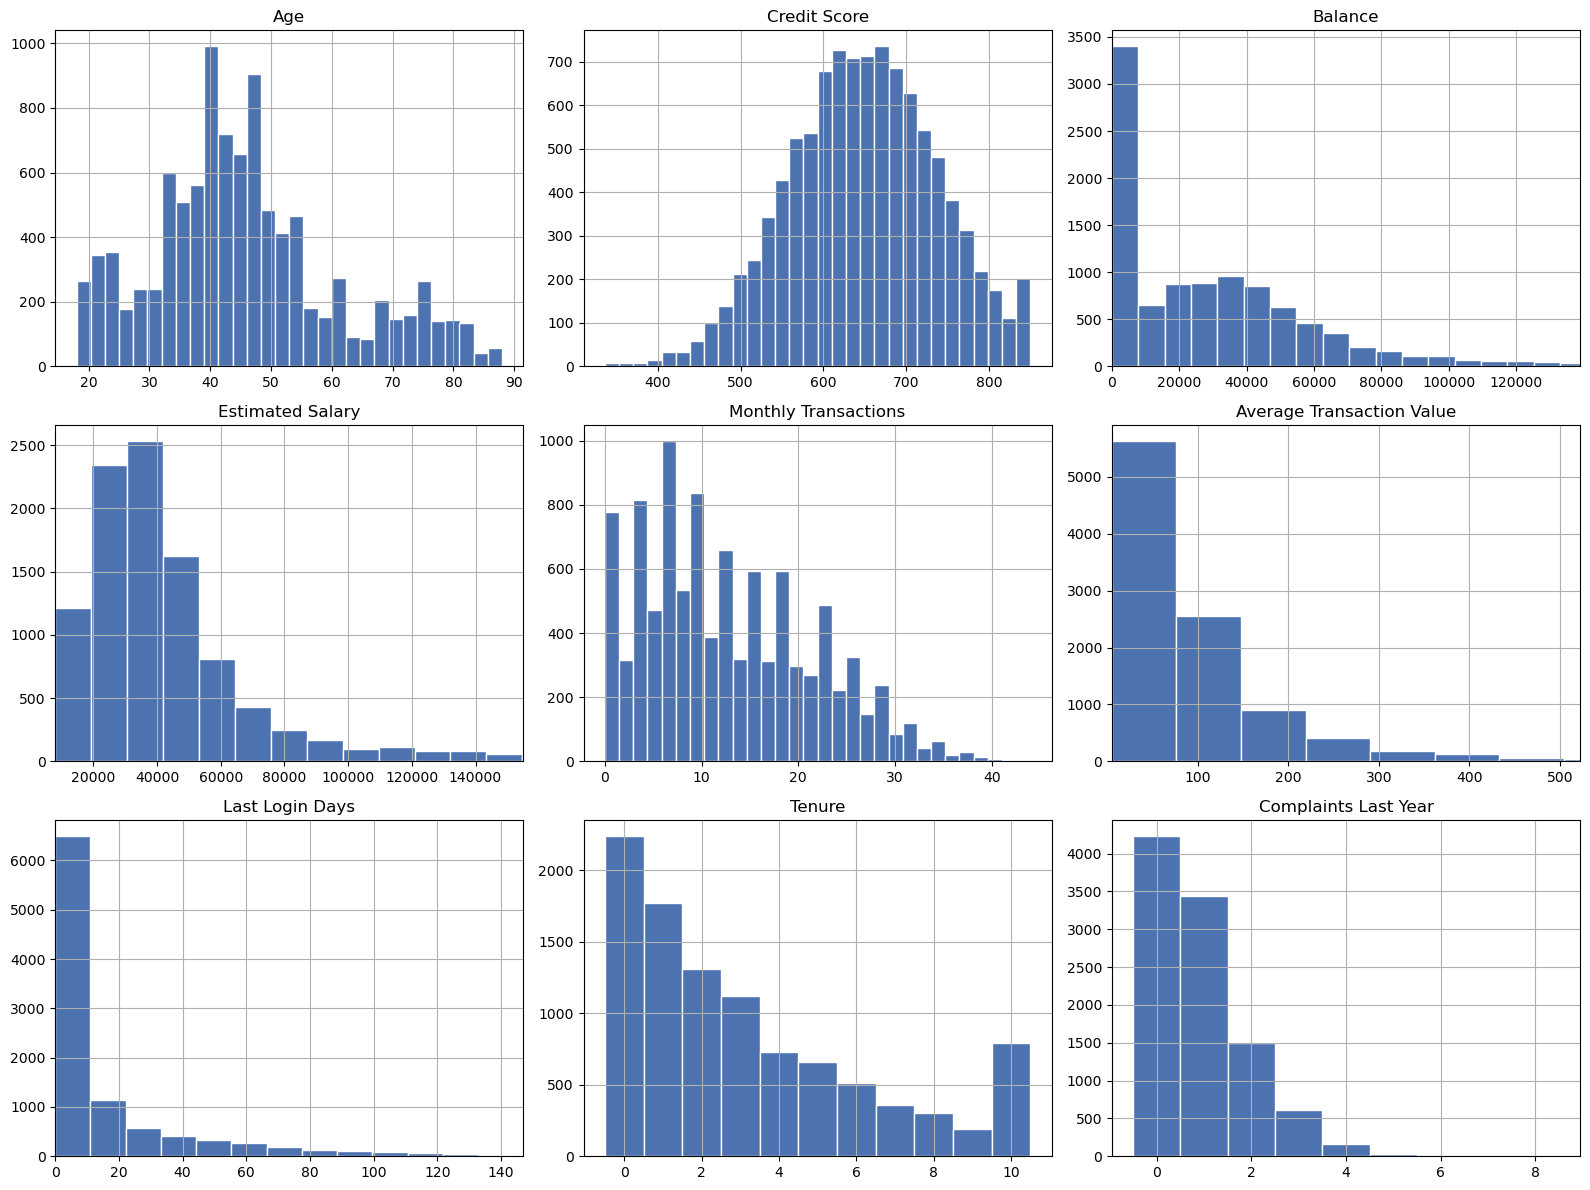

In [40]:
# Continuous variables - fine with 30 bins
continuous_cols = ["age", "credit_score", "balance", "estimated_salary",
                    "monthly_transactions", "average_transaction_value", "last_login_days"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    df[col].hist(bins=30, ax=axes[i], color="#4C72B0", edgecolor="white")
    axes[i].set_title(col.replace("_", " ").title())
    # Cap the x-axis at the 99th percentile for right-skewed variables,
    # so a handful of outliers don't compress the bulk of the data into a corner
    if col == "estimated_salary":
        axes[i].set_xlim(df[col].min(), df[col].quantile(0.98))
    elif col in ["balance", "average_transaction_value", "last_login_days"]:
        axes[i].set_xlim(df[col].min(), df[col].quantile(0.99))



# Discrete/count variables - use bins aligned to actual integer values
for i, col in enumerate(["tenure", "complaints_last_year"], start=len(continuous_cols)):
    bins = range(int(df[col].min()), int(df[col].max()) + 2)
    df[col].hist(bins=bins, ax=axes[i], color="#4C72B0", edgecolor="white", align="left")
    axes[i].set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [41]:
numeric_cols = continuous_cols + ["tenure", "complaints_last_year"]
df[numeric_cols].describe().round(2)

,age,credit_score,balance,estimated_salary,monthly_transactions,average_transaction_value,last_login_days,tenure,complaints_last_year
count,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00
mean,45.54,648.30,29917.53,44924.28,12.72,97.67,18.91,3.17,0.92
std,15.45,89.96,31680.70,33302.63,8.73,106.54,31.08,3.09,1.02
min,18.00,336.00,0.00,8000.00,0.00,5.00,0.00,0.00,0.00
25%,36.00,586.25,404.82,25889.49,6.00,36.23,2.00,1.00,0.00
50%,43.00,649.00,24399.99,36674.16,11.00,66.32,6.00,2.00,1.00
75%,53.00,711.00,45728.55,51307.37,19.00,120.36,21.00,5.00,1.00
max,88.00,850.00,234847.65,346518.21,44.00,2145.16,332.00,10.00,8.00


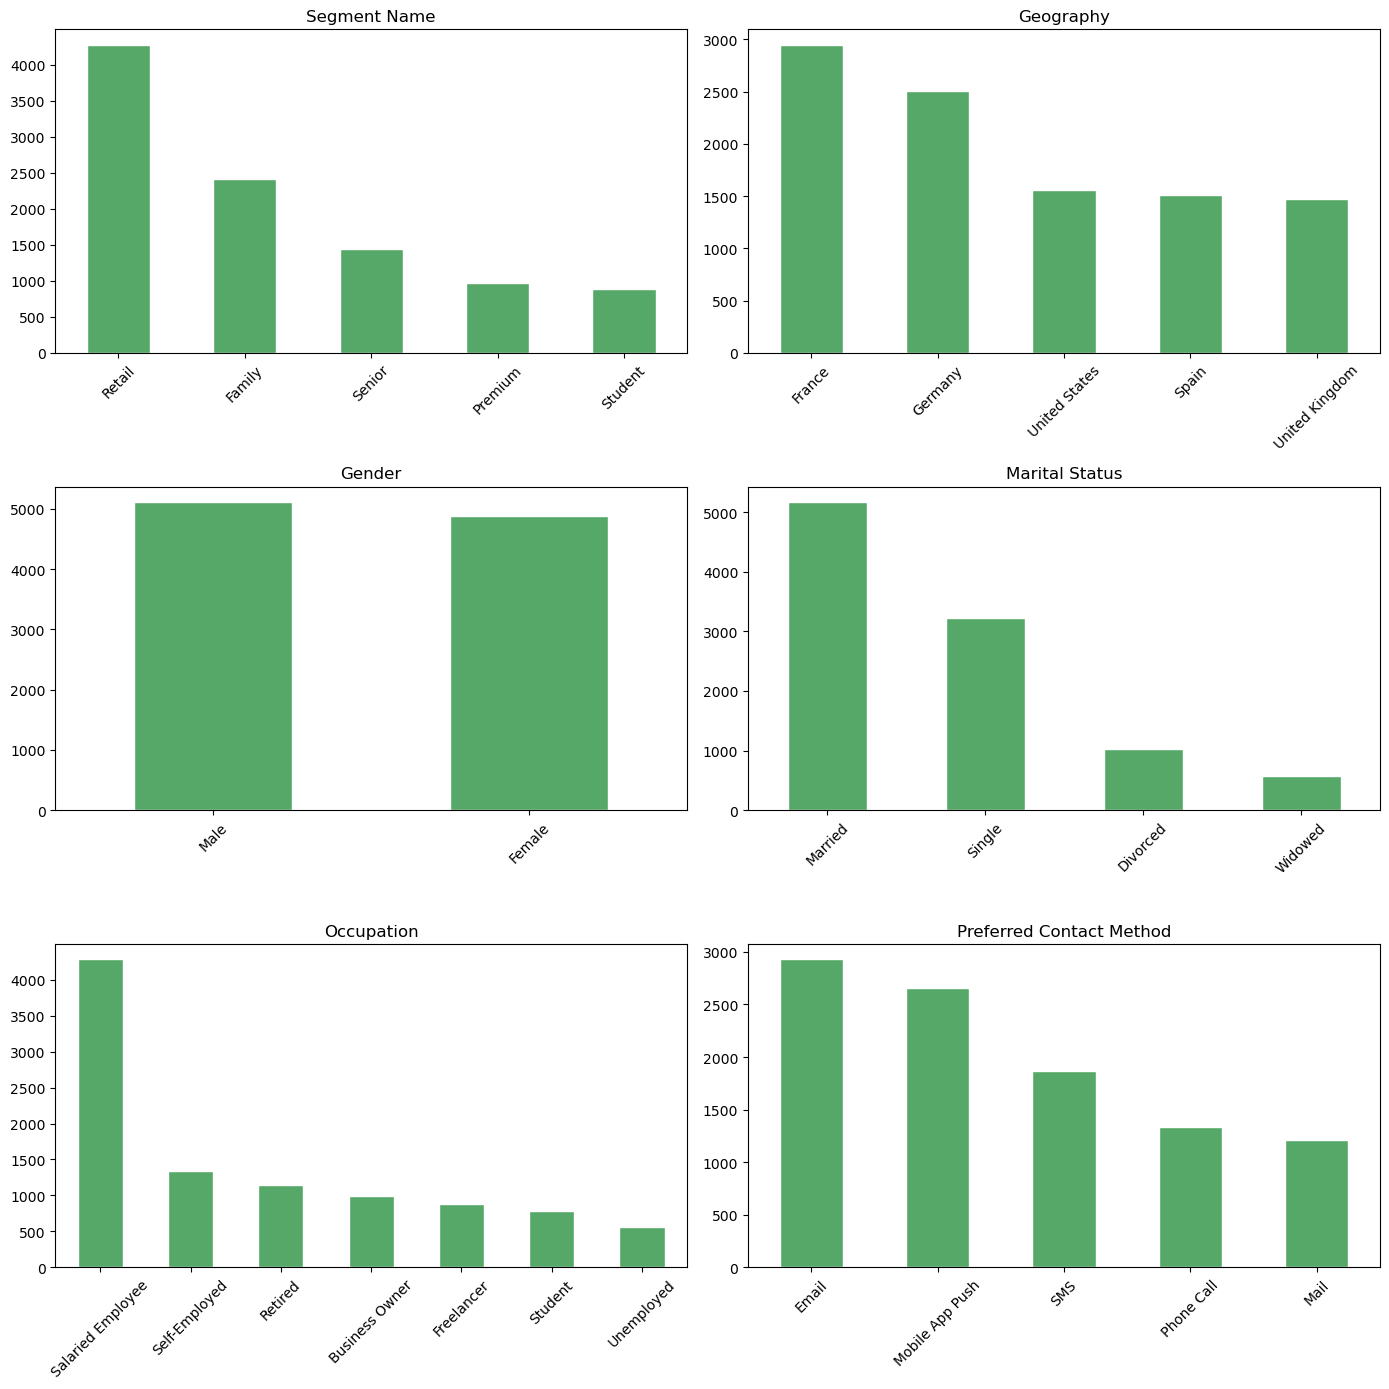

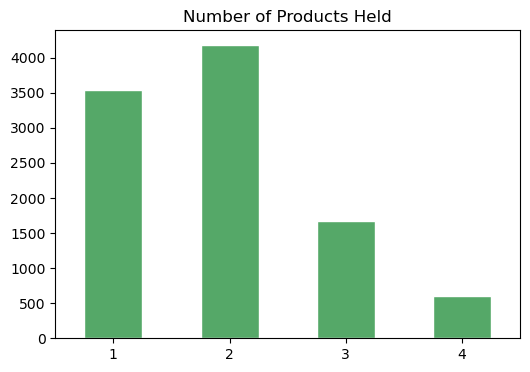

In [42]:
categorical_cols = ["segment_name", "geography", "gender", "marital_status",
                     "occupation", "preferred_contact_method"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    counts.plot(kind="bar", ax=axes[i], color="#55A868", edgecolor="white")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()


df["num_products"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="#55A868", edgecolor="white"
)
plt.title("Number of Products Held")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

## Note on SQL vs. Python Results

Minor differences (typically ≤0.06 percentage points) may appear between the SQL 
exploratory results and the Python analysis below. This is expected: SQL queries for 
segment-independent questions (Q4, Q5, Q6, Q7, Q9) ran directly against the full 
`customer_accounts` table (10,000 rows), while the Python analytical dataset (`df`) 
excludes 10 accounts with no matching customer record (see anti-join checks above), 
leaving 9,990 rows. Both figures are correct for what they measure — they simply 
reflect slightly different populations.

In [43]:
# -- Churn rate by category for cleaner analysis

def plot_churn_rate_by(column, title, order=None, figsize=(7,5)):
    churn_rate = df.groupby(column, observed=True)["exited"].mean().mul(100).round(2)
    if order is not None:
        churn_rate = churn_rate.reindex(order)
    else:
        churn_rate = churn_rate.sort_values(ascending=False)

    ax = churn_rate.plot(kind="bar", figsize=figsize, color="#C44E52", edgecolor="white")
    plt.title(title)
    plt.ylabel("Churn Rate (%)")
    plt.xlabel("")
    plt.xticks(rotation=45, ha="right")
    for i, v in enumerate(churn_rate):
        ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return churn_rate

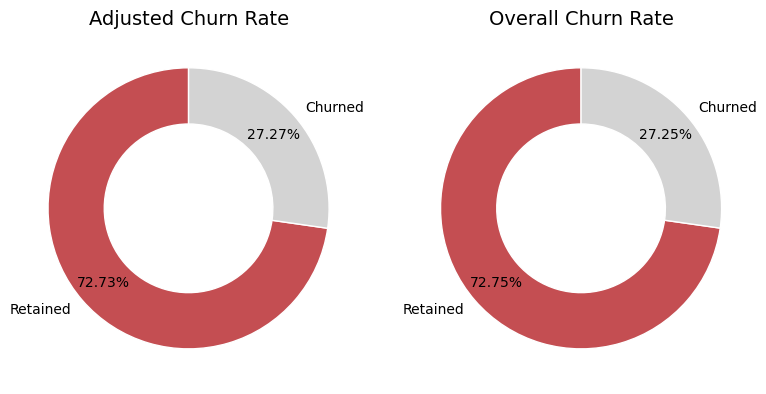

          Adjusted (9,990 accounts)  Overall (10,000 accounts)
Status                                                        
Retained                       7266                       7275
Churned                        2724                       2725


In [44]:
#-- Q1

churn_counts = df["exited"].value_counts()
churn_pct = df["exited"].value_counts(normalize=True) * 100

account_churn_counts = df_accounts["exited"].value_counts()
account_churn_pct = df_accounts["exited"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

wedges1, texts1, autotexts1 = axes[0].pie(
    churn_counts,
    labels=["Retained", "Churned"],
    autopct="%1.2f%%",
    pctdistance=0.8,
    colors=["#C44E52", "#D3D3D3"],
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)
axes[0].set_title("Adjusted Churn Rate", fontsize=14)

wedges2, texts2, autotexts2 = axes[1].pie(
    account_churn_counts,
    labels=["Retained", "Churned"],
    autopct="%1.2f%%",
    pctdistance=0.8,
    colors=["#C44E52", "#D3D3D3"],
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)
axes[1].set_title("Overall Churn Rate", fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()

comparison = pd.concat(
    [churn_counts, account_churn_counts],
    axis=1,
    keys=["Adjusted (9,990 accounts)", "Overall (10,000 accounts)"]
)

comparison.index = comparison.index.map({0: "Retained", 1: "Churned"})
comparison.index.name = "Status"

print(comparison)

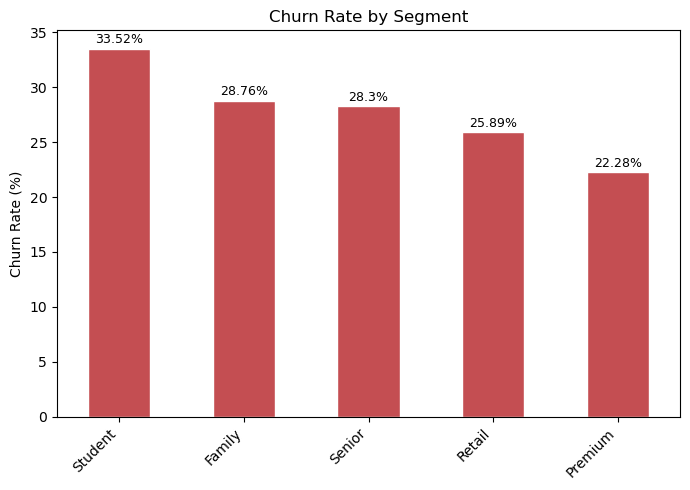

segment_name
Student    33.52
Family     28.76
Senior     28.30
Retail     25.89
Premium    22.28
Name: exited, dtype: float64

In [45]:
# -- Q2

plot_churn_rate_by("segment_name", "Churn Rate by Segment")

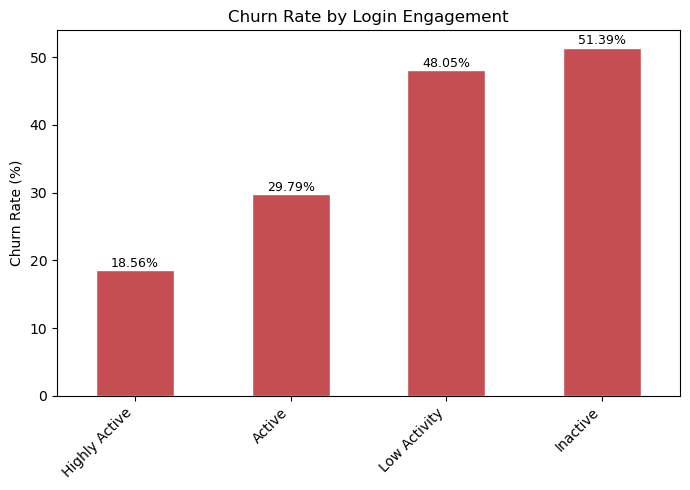

login_engagement
Highly Active    18.56
Active           29.79
Low Activity     48.05
Inactive         51.39
Name: exited, dtype: float64

In [46]:
# -- Q3

plot_churn_rate_by("login_engagement", "Churn Rate by Login Engagement",
                    order=["Highly Active","Active","Low Activity","Inactive"])

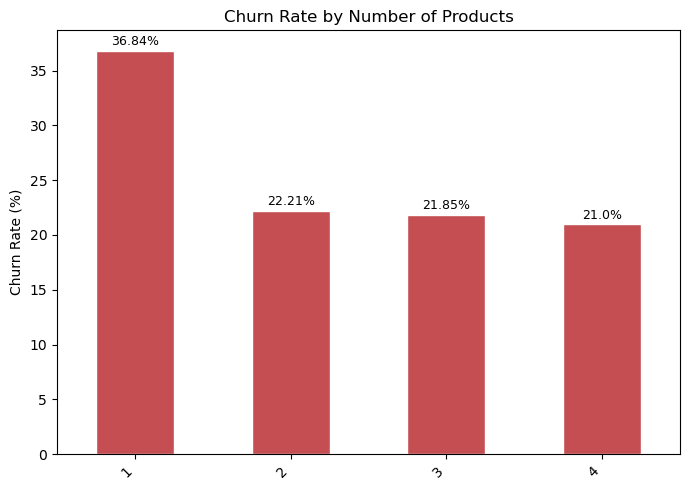

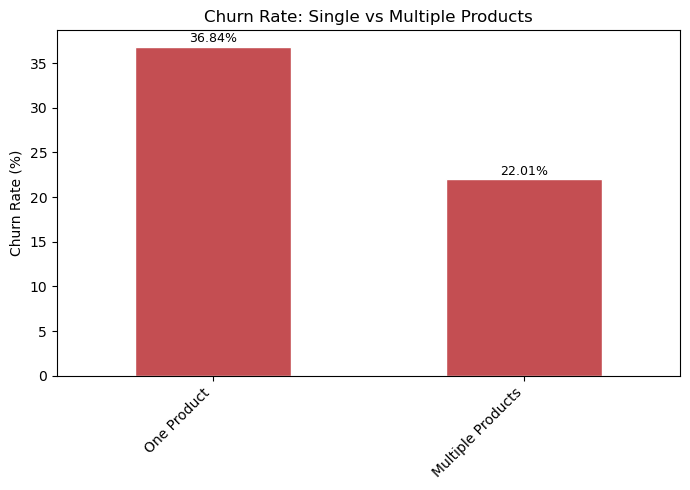

product_group
One Product          36.84
Multiple Products    22.01
Name: exited, dtype: float64

In [47]:
# -- Q4

plot_churn_rate_by("num_products", "Churn Rate by Number of Products")
plot_churn_rate_by("product_group", "Churn Rate: Single vs Multiple Products")

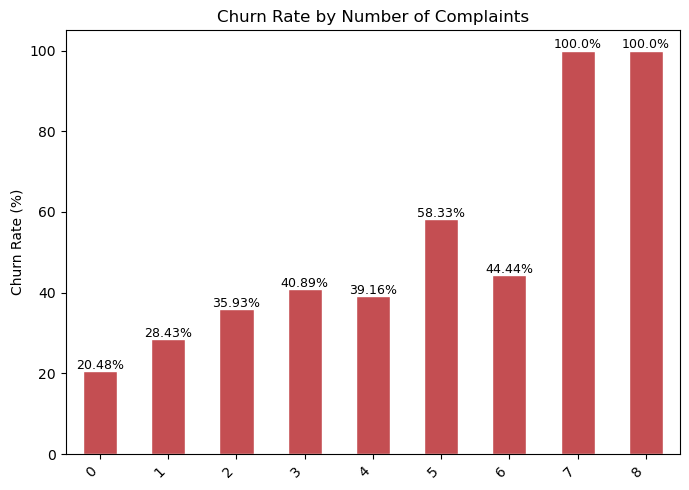

complaints_last_year
0     20.48
1     28.43
2     35.93
3     40.89
4     39.16
5     58.33
6     44.44
7    100.00
8    100.00
Name: exited, dtype: float64

In [48]:
# -- Q5

plot_churn_rate_by("complaints_last_year", "Churn Rate by Number of Complaints",
                    order=sorted(df["complaints_last_year"].unique()))

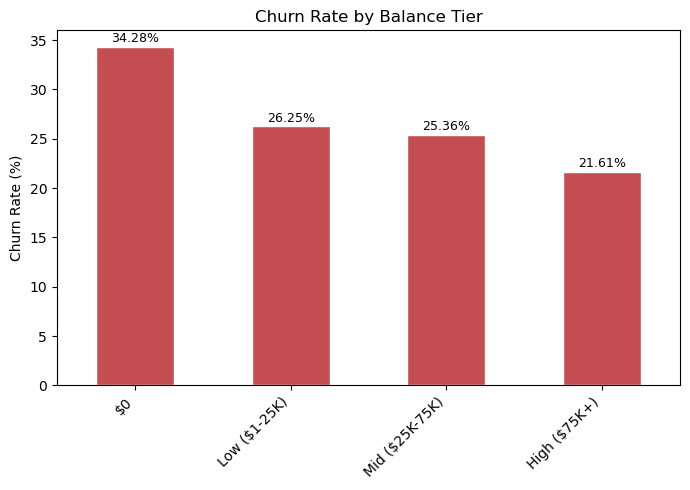

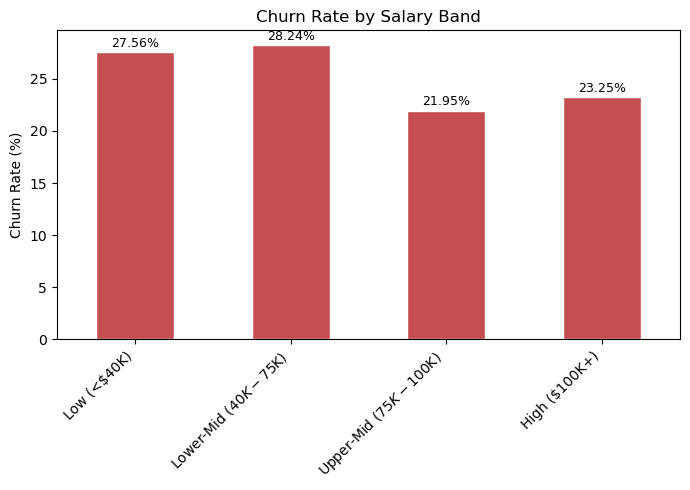

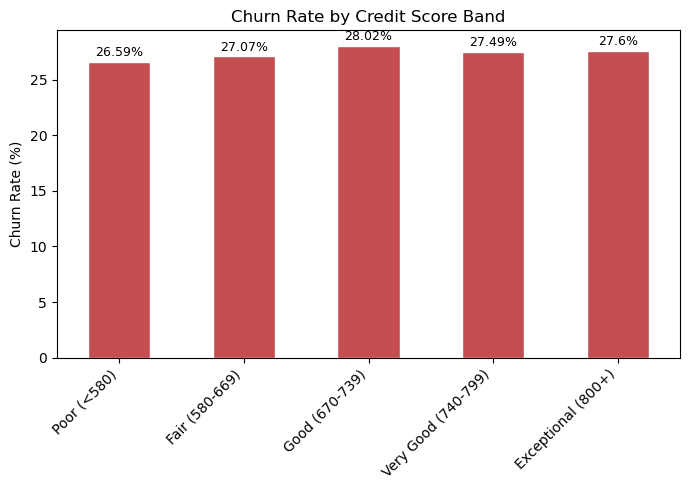

credit_score_band
Poor (<580)            26.59
Fair (580-669)         27.07
Good (670-739)         28.02
Very Good (740-799)    27.49
Exceptional (800+)     27.60
Name: exited, dtype: float64

In [49]:
# -- Q6

plot_churn_rate_by("balance_tier", "Churn Rate by Balance Tier",
                    order=["$0","Low ($1-25K)","Mid ($25K-75K)","High ($75K+)"])

plot_churn_rate_by("salary_band", "Churn Rate by Salary Band",
                    order=["Low (<$40K)","Lower-Mid ($40K-$75K)","Upper-Mid ($75K-$100K)","High ($100K+)"])

plot_churn_rate_by("credit_score_band", "Churn Rate by Credit Score Band",
                    order=["Poor (<580)","Fair (580-669)","Good (670-739)","Very Good (740-799)","Exceptional (800+)"])

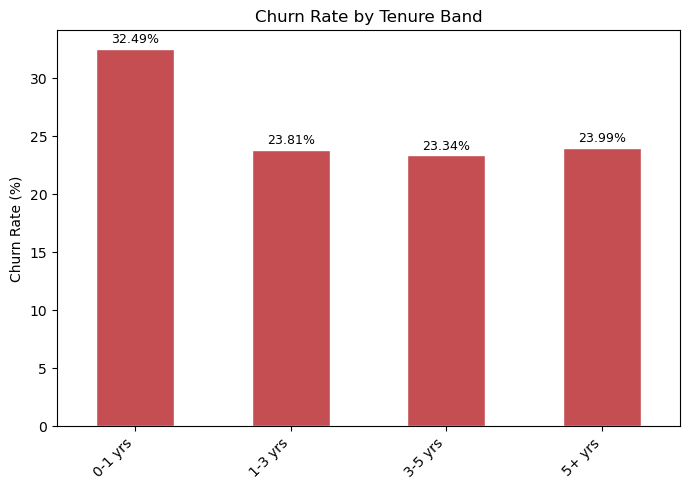

tenure_band
0-1 yrs    32.49
1-3 yrs    23.81
3-5 yrs    23.34
5+ yrs     23.99
Name: exited, dtype: float64

In [50]:
# -- Q7

plot_churn_rate_by("tenure_band", "Churn Rate by Tenure Band",
                    order=["0-1 yrs","1-3 yrs","3-5 yrs","5+ yrs"])

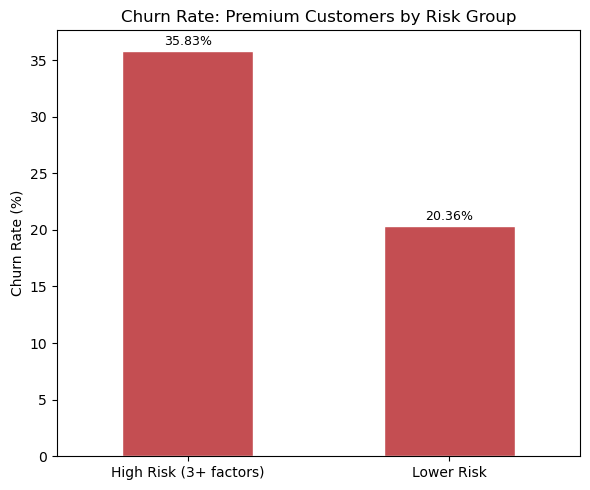

risk_group
High Risk (3+ factors)    35.83
Lower Risk                20.36
Name: exited, dtype: float64
risk_group
Lower Risk                845
High Risk (3+ factors)    120
Name: count, dtype: int64


In [51]:
# -- Q8

premium = df[df["segment_name"] == "Premium"]
premium_churn = premium.groupby("risk_group")["exited"].mean().mul(100).round(2)

ax = premium_churn.plot(kind="bar", figsize=(6,5), color="#C44E52", edgecolor="white")
plt.title("Churn Rate: Premium Customers by Risk Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=0)
for i, v in enumerate(premium_churn):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(premium_churn)
print(premium["risk_group"].value_counts())

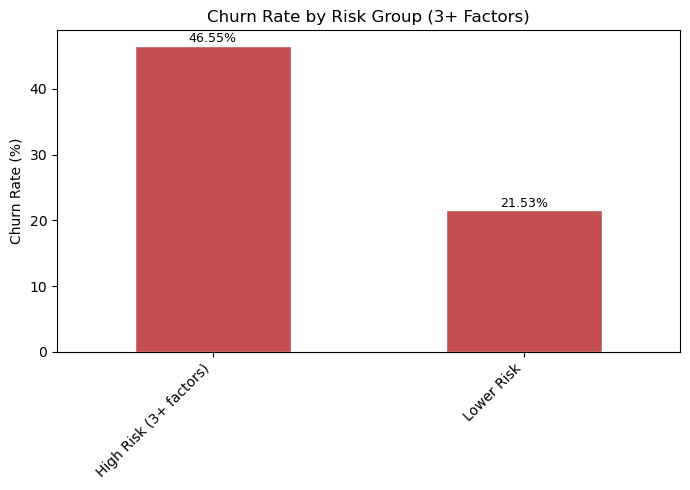

risk_group
High Risk (3+ factors)    46.55
Lower Risk                21.53
Name: exited, dtype: float64

In [52]:
# -- Q9

plot_churn_rate_by("risk_group", "Churn Rate by Risk Group (3+ Factors)")

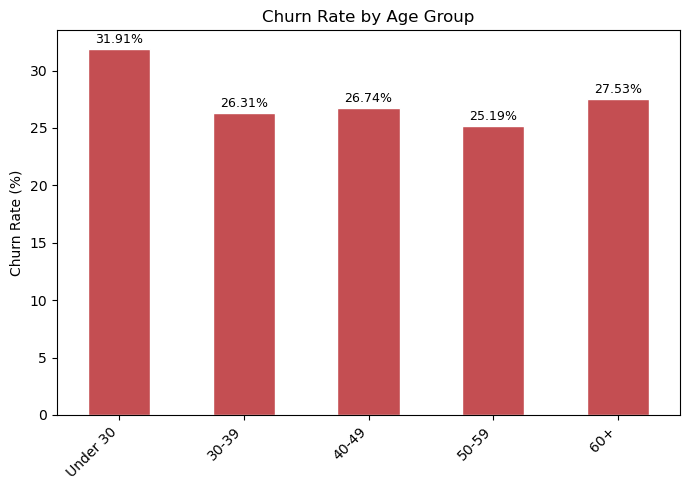

age_group
Under 30    31.91
30-39       26.31
40-49       26.74
50-59       25.19
60+         27.53
Name: exited, dtype: float64

In [53]:
# -- Age

plot_churn_rate_by("age_group", "Churn Rate by Age Group",
                    order=["Under 30","30-39","40-49","50-59","60+"])

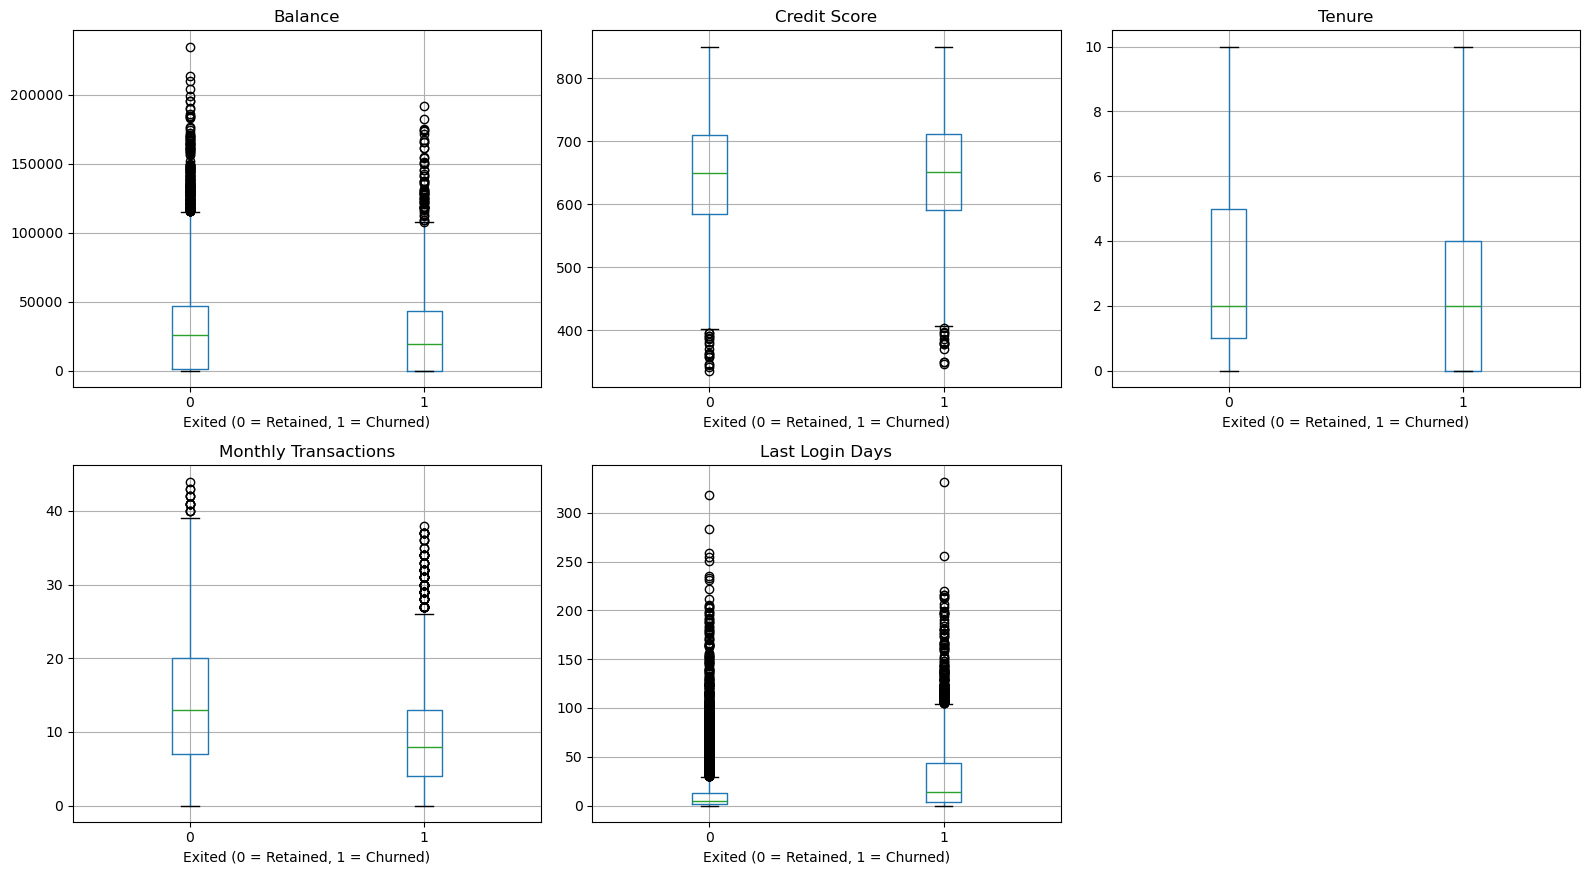

In [54]:
# -- Boxplots

box_cols = ["balance", "credit_score", "tenure", "monthly_transactions", "last_login_days"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    df.boxplot(column=col, by="exited", ax=axes[i])
    axes[i].set_title(col.replace("_"," ").title())
    axes[i].set_xlabel("Exited (0 = Retained, 1 = Churned)")

axes[-1].axis("off")  # hide the unused 6th subplot
plt.suptitle("")  # remove pandas' default overall title
plt.tight_layout()
plt.show()

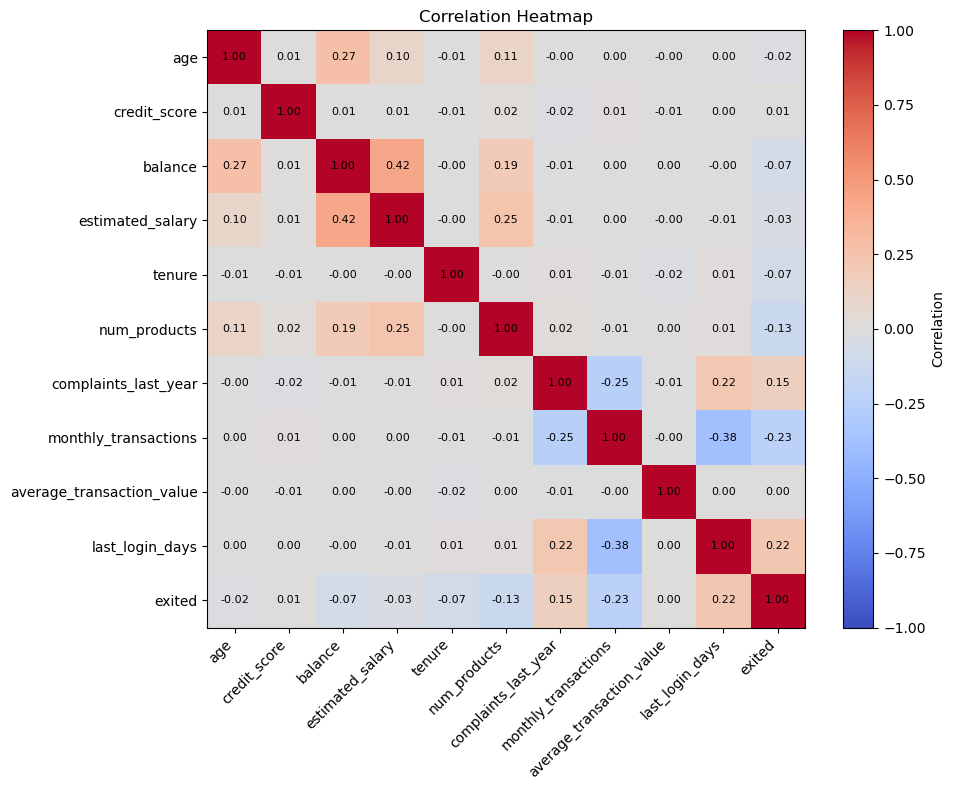

In [55]:
# -- Correlation heatmap

corr_cols = ["age","credit_score","balance","estimated_salary","tenure",
             "num_products","complaints_last_year","monthly_transactions",
             "average_transaction_value","last_login_days","exited"]

plt.figure(figsize=(10,8))
corr = df[corr_cols].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [56]:
# -- Chi-square tests

def chi_square_test(column, label):
    contingency = pd.crosstab(df[column], df["exited"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    result = "significant" if p < 0.05 else "not significant"
    print(f"{label}")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  p-value: {p:.6f}  →  {result} at α=0.05")
    print()
    return p

chi_results = {}
chi_results["Segment"] = chi_square_test("segment_name", "Segment vs. Churn")
chi_results["Login Engagement"] = chi_square_test("login_engagement", "Login Engagement vs. Churn")
chi_results["Product Group"] = chi_square_test("product_group", "Product Group (Single vs Multiple) vs. Churn")
chi_results["Complaints"] = chi_square_test("complaint_flag", "Complaint Flag vs. Churn")
chi_results["Risk Group"] = chi_square_test("risk_group", "Risk Group (3+ Factors) vs. Churn")
chi_results["Geography"] = chi_square_test("geography", "Geography vs. Churn")
chi_results["Gender"] = chi_square_test("gender", "Gender vs. Churn")
chi_results["Marital Status"] = chi_square_test("marital_status", "Marital Status vs. Churn")

Segment vs. Churn
  Chi-square statistic: 37.23
  p-value: 0.000000  →  significant at α=0.05

Login Engagement vs. Churn
  Chi-square statistic: 669.04
  p-value: 0.000000  →  significant at α=0.05

Product Group (Single vs Multiple) vs. Churn
  Chi-square statistic: 253.01
  p-value: 0.000000  →  significant at α=0.05

Complaint Flag vs. Churn
  Chi-square statistic: 169.56
  p-value: 0.000000  →  significant at α=0.05

Risk Group (3+ Factors) vs. Churn
  Chi-square statistic: 555.78
  p-value: 0.000000  →  significant at α=0.05

Geography vs. Churn
  Chi-square statistic: 1.21
  p-value: 0.875696  →  not significant at α=0.05

Gender vs. Churn
  Chi-square statistic: 0.68
  p-value: 0.410165  →  not significant at α=0.05

Marital Status vs. Churn
  Chi-square statistic: 5.04
  p-value: 0.168616  →  not significant at α=0.05



In [57]:
# -- T-tests

def t_test(column, label):
    churned = df[df["exited"] == 1][column]
    retained = df[df["exited"] == 0][column]
    t_stat, p = ttest_ind(churned, retained, equal_var=False) 
    result = "significant" if p < 0.05 else "not significant"
    print(f"{label}")
    print(f"  Churned mean: {churned.mean():.2f}  |  Retained mean: {retained.mean():.2f}")
    print(f"  t-statistic: {t_stat:.2f}")
    print(f"  p-value: {p:.6f}  →  {result} at α=0.05")
    print()
    return p

t_results = {}
t_results["Balance"] = t_test("balance", "Balance: Churned vs. Retained")
t_results["Tenure"] = t_test("tenure", "Tenure: Churned vs. Retained")
t_results["Credit Score"] = t_test("credit_score", "Credit Score: Churned vs. Retained")
t_results["Estimated Salary"] = t_test("estimated_salary", "Estimated Salary: Churned vs. Retained")
t_results["Monthly Transactions"] = t_test("monthly_transactions", "Monthly Transactions: Churned vs. Retained")
t_results["Last Login Days"] = t_test("last_login_days", "Last Login Days: Churned vs. Retained")
t_results["Age"] = t_test("age", "Age: Churned vs. Retained")

Balance: Churned vs. Retained
  Churned mean: 26538.09  |  Retained mean: 31184.48
  t-statistic: -6.70
  p-value: 0.000000  →  significant at α=0.05

Tenure: Churned vs. Retained
  Churned mean: 2.80  |  Retained mean: 3.31
  t-statistic: -7.47
  p-value: 0.000000  →  significant at α=0.05

Credit Score: Churned vs. Retained
  Churned mean: 649.39  |  Retained mean: 647.90
  t-statistic: 0.74
  p-value: 0.459798  →  not significant at α=0.05

Estimated Salary: Churned vs. Retained
  Churned mean: 43089.02  |  Retained mean: 45612.32
  t-statistic: -3.53
  p-value: 0.000416  →  significant at α=0.05

Monthly Transactions: Churned vs. Retained
  Churned mean: 9.45  |  Retained mean: 13.94
  t-statistic: -25.12
  p-value: 0.000000  →  significant at α=0.05

Last Login Days: Churned vs. Retained
  Churned mean: 30.16  |  Retained mean: 14.69
  t-statistic: 19.62
  p-value: 0.000000  →  significant at α=0.05

Age: Churned vs. Retained
  Churned mean: 45.04  |  Retained mean: 45.73
  t-stat

In [58]:
# -- Summary with significance threshold

summary = pd.DataFrame({
    "Test": list(chi_results.keys()) + list(t_results.keys()),
    "Type": ["Chi-square"]*len(chi_results) + ["T-test"]*len(t_results),
    "p-value": list(chi_results.values()) + list(t_results.values())
})
summary["Significant (α=0.05)"] = summary["p-value"] < 0.05
summary = summary.sort_values("p-value")
summary

,Test,Type,p-value,Significant (α=0.05)
1,Login Engagement,Chi-square,1.083892e-144,True
12,Monthly Transactions,T-test,5.413310e-132,True
4,Risk Group,Chi-square,6.965706e-123,True
13,Last Login Days,T-test,9.462331e-82,True
2,Product Group,Chi-square,5.737693e-57,True
3,Complaints,Chi-square,9.254599e-39,True
9,Tenure,T-test,9.367020e-14,True
8,Balance,T-test,2.242334e-11,True
0,Segment,Chi-square,1.616488e-07,True
11,Estimated Salary,T-test,4.155202e-04,True


## Key Findings

Of the 10,000 customer accounts analyzed, **2,725 have churned — an overall churn rate 
of 27.25%**. The following behavioural and financial factors showed the strongest, 
statistically significant relationships with churn:

**1. Engagement is the strongest observed churn signal in the analysis.**
Customers grouped by login recency show a clear relationship between inactivity and churn — 
Highly Active customers churn at just 18.56%, compared to 51.39% for Inactive customers 
(those who haven't logged in for 90+ days). This nearly 33-point spread, confirmed by a 
chi-square test (p < 0.001), is by far the largest gap found in the dataset.

**2. Single-product customers are a clear flight risk.**
Customers holding only 1 product churn at 36.84%, compared to 22.01% for those 
holding 2-4 products — a 14.83 percentage-point gap. Single-product customers also carry 
a lower average balance, meaning this group is simultaneously higher-risk and lower-value.

**3. Complaints are strongly associated with churn.**
Churn rises steadily as complaint count increases, from 20.48% at 0 complaints to an average  
of 40.52% by 3-4 complaints (chi-square p < 0.001). Categories beyond 4 complaints have too few 
accounts (fewer than 10 each) to draw reliable conclusions.

**4. A \\$0 balance is a strong, immediate risk signal.**
Customers with a \\$0 balance churn at 34.28%, meaningfully higher than any other balance
tier (Low: 26.25%, Mid: 25.36%, High: 21.61%). A t-test confirms churned customers carry
significantly lower average balances than retained customers (\\$26,538 vs. \\$31,184).

**5. Newer customers are more likely to leave.**
Customers in their first year (tenure ≤ 1) churn at 32.49%, roughly 8-9 percentage points 
higher than any longer-tenured group, confirmed by a significant t-test (p < 0.001).

**6. High-value ("Premium") customers are not uniformly safe.**
While Premium customers churn at a lower rate overall (22.28%) than the customer base as 
a whole, this average hides real variation: 120 of 965 Premium customers (12.44%) meet 3 or 
more established risk criteria, and this subgroup churns at 35.83% — well above both the 
Premium average and the overall baseline — versus just 20.36% for lower-risk Premium 
customers. High account value does not protect against the same behavioural risk factors 
seen elsewhere in the bank.

**7. Combining risk factors is associated with substantially higher churn risk.**
Customers with 3 or more risk factors (engagement, single product, complaints, \\$0 balance, 
or short tenure) churn at 46.55%, compared to 21.53% for customers with fewer than 3 — a
25.02 percentage-point gap on a chi-square test significant at p < 0.001. The combined risk profile
shows a substantially stronger observed association with churn than individual risk signals.

## Factors With No Statistically Significant Association

Several variables were tested and found to have no statistically significant relationship 
with churn:

- **Geography** (p = 0.876)
- **Gender** (p = 0.410)
- **Marital status** (p = 0.169)
- **Credit score** (p = 0.460) — churn rates across all credit bands stayed within 
  roughly 2 percentage points of each other

Within this dataset, these variables did not show statistically significant relationships 
with churn, suggesting that retention efforts may be more effectively focused on behavioural 
and engagement signals.  

In [59]:
kpi_data = {
    "Key Metrics": [
        "Overall churn rate",
        "Churn rate by segment",
        "Customers in 'Inactive' login tier (90+ days)",
        "Churn rate by login engagement tier",
        "Customers holding only 1 product",
        "Churn rate by product count",
        "Churn rate by complaint count (0 vs 1+)",
        "Accounts with $0 balance",
        "Churn rate by balance tier",
        "Customers with tenure ≤ 1 year",
        "High-risk Premium churn rate (3+ factors)",
        "Customer base meeting 3+ risk factors",
        "Churn rate: 3+ risk factors vs. fewer than 3",
    ],
    "Current Value": [
        "27.25%", "22.28% (Premium) – 33.52% (Student)", "4.30%",
        "18.56% – 51.39%", "35.50%", "22.01% (2-4) – 36.84% (1)",
        "20.48% – 40.52%+", "21.90%", "21.61% – 34.28%", "40.10%",
        "35.83%", "22.92%", "21.53% – 46.55%"
    ]
}
kpi_df = pd.DataFrame(kpi_data)
kpi_df

,Key Metrics,Current Value
0,Overall churn rate,27.25%
1,Churn rate by segment,22.28% (Premium) – 33.52% (Student)
2,Customers in 'Inactive' login tier (90+ days),4.30%
3,Churn rate by login engagement tier,18.56% – 51.39%
4,Customers holding only 1 product,35.50%
5,Churn rate by product count,22.01% (2-4) – 36.84% (1)
6,Churn rate by complaint count (0 vs 1+),20.48% – 40.52%+
7,Accounts with $0 balance,21.90%
8,Churn rate by balance tier,21.61% – 34.28%
9,Customers with tenure ≤ 1 year,40.10%


## Recommendations

Based on the findings above, the following retention actions are recommended, ordered by the strength of the underlying signal:

- **Build an engagement-based early-warning trigger.** Login recency shows the strongest observed relationship with churn, so flag customers as they cross the 30-day and 90-day login-gap thresholds for proactive outreach — well before they reach the 51.39% churn rate seen in the Inactive tier.

- **Prioritize cross-sell for single-product customers.** This group is both the highest-churn and lowest-value segment — customers with one product churn at 36.84% versus 22.01% for those holding 2-4 products, making it a strong candidate for targeted product education and cross-sell outreach.

- **Treat any complaint as a retention touchpoint, not just a service ticket.** Churn rises steadily with complaint count — fast resolution and proactive follow-up after a first complaint could interrupt this trend before it compounds.

- **Do not assume Premium customers are safe.** Build a specific monitoring view for the 12.44% of Premium customers who meet 3+ risk factors — this subgroup churns at roughly 1.6x the segment's average rate and represents a high-value population the bank is currently at risk of losing without any targeted intervention.

- **Use the 3+ risk-factor group as a prioritization segment for retention outreach.** This metric outperforms any single factor and identifies a genuinely actionable 22.92% of the customer base for prioritized retention outreach.

- **Deprioritize demographic-based targeting.** Geography, gender, and marital status showed no meaningful relationship with churn — retention budget is better spent on behavioural triggers than demographic segmentation.

## Limitations

- This dataset is synthetic, generated to mimic realistic banking data patterns rather 
  than sourced from an actual institution; findings demonstrate analytical methodology 
  rather than real-world banking behaviour.
- 10 accounts (0.1%) could not be matched to a customer record and were excluded from 
  the Python analysis (though included in SQL's account-level queries), producing minor 
  (≤0.06 percentage point) differences between the two — see note above Phase 6.
- 9 customers (0.09%) had an unresolved segment reference; these were retained in the 
  overall dataset and flagged "Unknown," but excluded from segment-level comparisons.
- T-tests assume approximately normal distributions; results for right-skewed variables
  (e.g., balance, transaction value) are robust at this sample size, but should be
  interpreted with that in mind.
- This analysis identifies associations with churn but does not establish causal relationships.
- The 3+ risk-factor threshold was created for exploratory customer segmentation and has not
  been validated as a predictive scoring model.
- The dataset represents a single analytical sample and may not generalize to other customer
  populations or time periods.
- Customers with unresolved segment mappings were retained for analyses that did not require
  segment classification.
- Further validation using historical customer behaviour and out-of-time data would be required
  before deploying the risk framework operationally.